=== Construindo matriz de acessibilidade entre bares ===

  Atenção: calcular caminhos para 40 bares requer até 780 pares únicos.
Isso pode levar de 2 a 5 minutos dependendo do hardware.

✅ Identificados 40 bares no grafo viário.
Calculando matriz de TEMPO de viagem (segundos)...

Calculando matriz de DISTÂNCIA geográfica (metros)...
=== Estatísticas de acessibilidade por bar ===

 TOP 10 bares mais acessíveis (menor tempo médio de viagem):

  1. BAR BATATA D'MOLA
     ⏱️  Média: 4.6 min | Mediana: 3.5 min
     📍 Distância média: 4.04 km
     🌐 Cobertura: 100% da rede

  2. BAR DO MARQUIM
     ⏱️  Média: 4.6 min | Mediana: 3.4 min
     📍 Distância média: 4.06 km
     🌐 Cobertura: 100% da rede

  3. CAMINHO DA ROCA
     ⏱️  Média: 4.8 min | Mediana: 3.6 min
     📍 Distância média: 4.26 km
     🌐 Cobertura: 100% da rede

  4. BAR DO ABILIO
     ⏱️  Média: 5.0 min | Mediana: 3.7 min
     📍 Distância média: 4.30 km
     🌐 Cobertura: 100% da rede

  5. REZA FORTE
     ⏱️  Média: 5.0 min | M

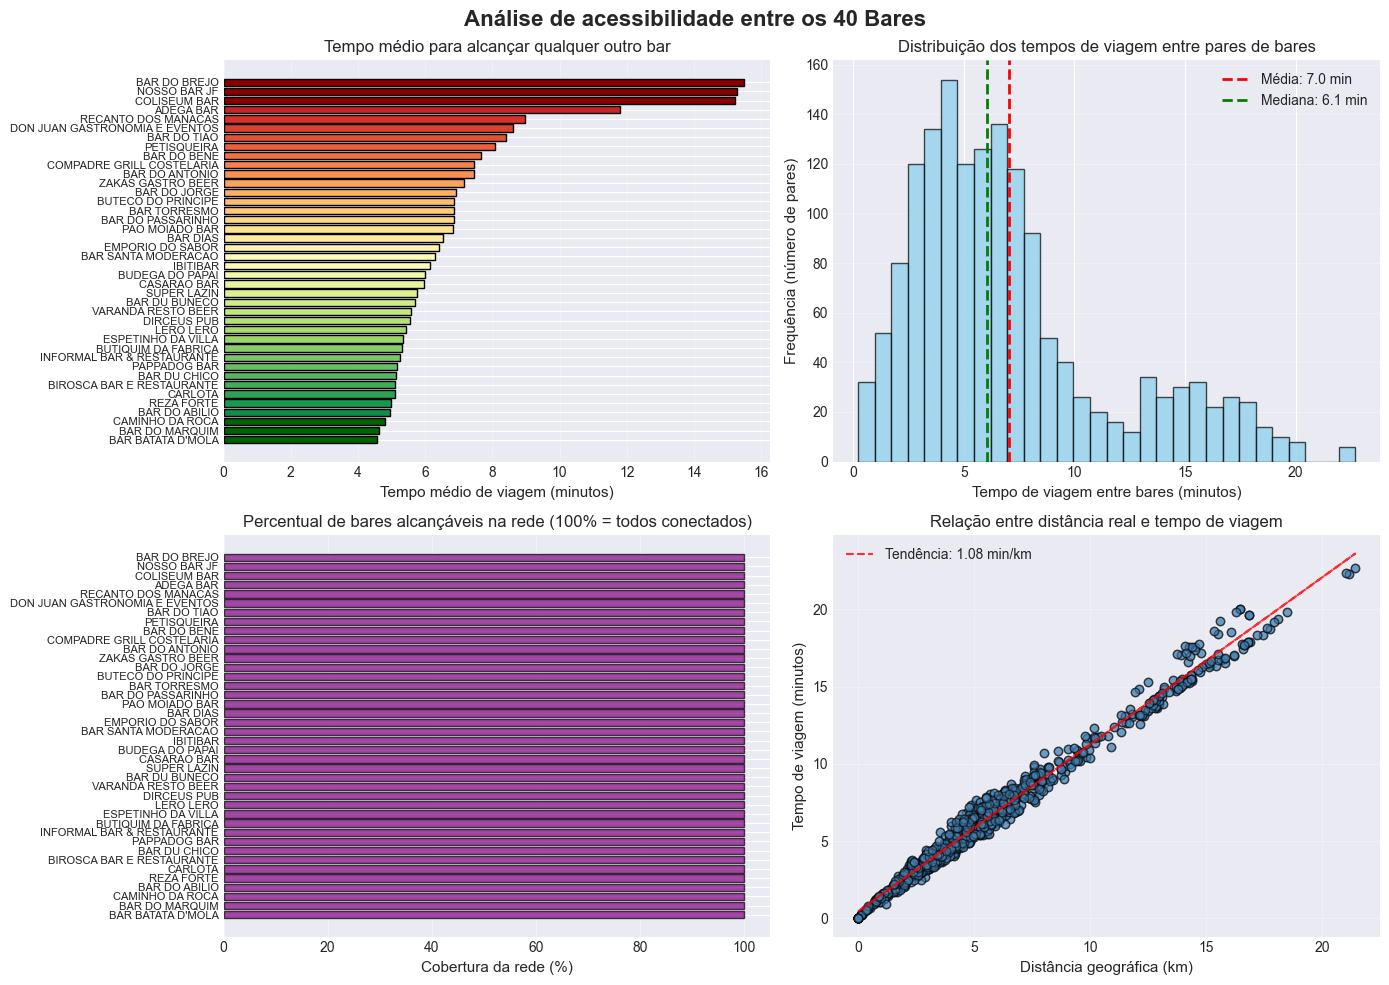

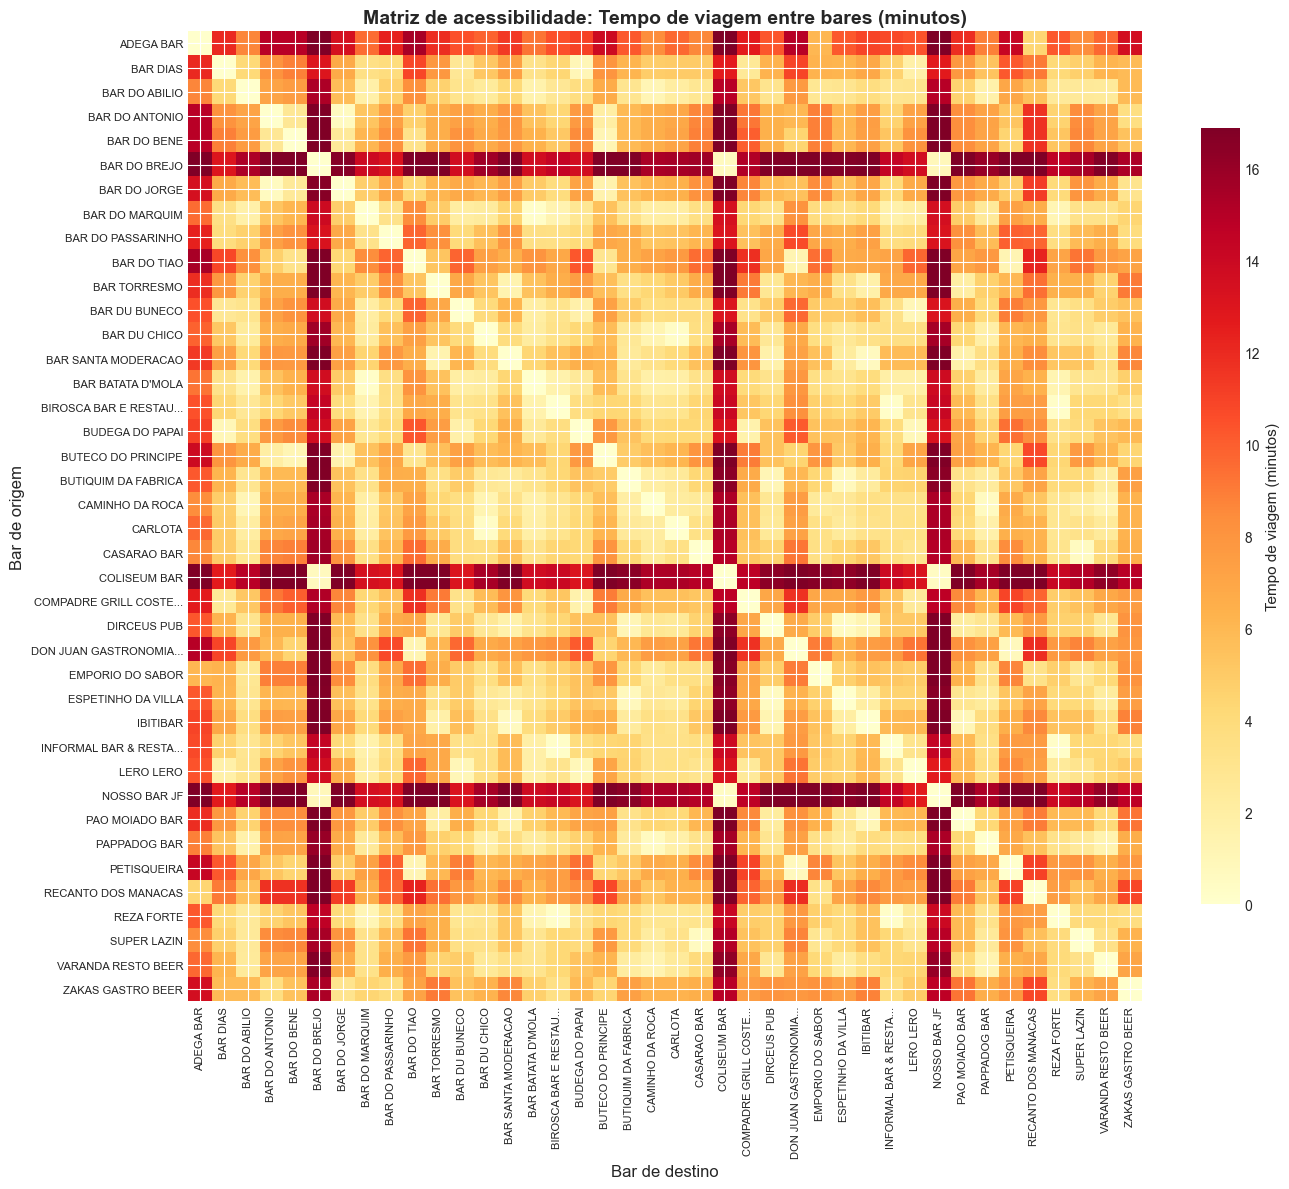

 Interpretação da matriz de calor:
- Linhas (origem) × Colunas (destino) = tempo de viagem
- Células mais claras (amarelo/branco) = menor tempo
- Células mais escuras (vermelho/marrom) = maior tempo
- Células em branco = bares não conectados (sem rota viável)
=== Score integrado de acessibilidade ===

 TOP 10 bares por acessibilidade integrada (maior score = melhor):

  1. BAR BATATA D'MOLA
     📊 Score final: 80.0/100
        └─ Tempo: 100.0 | Distância: 100.0 | Cobertura: 0.0
     ⏱️  Tempo médio: 4.6 min
     📍 Distância média: 4.04 km

  2. BAR DO MARQUIM
     📊 Score final: 79.6/100
        └─ Tempo: 99.4 | Distância: 99.8 | Cobertura: 0.0
     ⏱️  Tempo médio: 4.6 min
     📍 Distância média: 4.06 km

  3. CAMINHO DA ROCA
     📊 Score final: 78.3/100
        └─ Tempo: 97.9 | Distância: 97.7 | Cobertura: 0.0
     ⏱️  Tempo médio: 4.8 min
     📍 Distância média: 4.26 km

  4. BAR DO ABILIO
     📊 Score final: 77.4/100
        └─ Tempo: 96.5 | Distância: 97.3 | Cobertura: 0.0
     ⏱️

In [1]:
# # Análise de Acessibilidade entre Bares
# 
# Esta seção calcula e compara a acessibilidade entre todos os 40 bares,
# gerando métricas como:
# - Matriz de distâncias (tempo e distância geográfica)
# - Estatísticas de acessibilidade por bar
# - Ranking dos bares mais e menos acessíveis
# - Visualizações comparativas

# In[1]:


import pandas as pd
import numpy as np
import networkx as nx
import osmnx as ox
import folium
from folium.plugins import Fullscreen
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ## 1. Matriz de acessibilidade (tempo de viagem)

# In[2]:


print("=== Construindo matriz de acessibilidade entre bares ===\n")
print("  Atenção: calcular caminhos para 40 bares requer até 780 pares únicos.")
print("Isso pode levar de 2 a 5 minutos dependendo do hardware.\n")

gdf = pd.read_csv("lista_bares.csv")
X = np.array(gdf[['latitude', 'longitude']])

# Calcular o centro geográfico dos bares
center = (X[:, 0].mean(), X[:, 1].mean())

# Criar o grafo a partir do ponto central (raio de 25 km)
G = ox.graph_from_point(center, dist=25000, network_type='drive')

# Adicionar atributos de velocidade e tempo de viagem
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Identificar o nó mais próximo no grafo para cada bar
bar_nodes = []
bar_names = []

for idx, row in gdf.iterrows():
    nearest = ox.nearest_nodes(G, row['longitude'], row['latitude'])
    bar_nodes.append(nearest)
    bar_names.append(row['Name'])

print(f"✅ Identificados {len(bar_nodes)} bares no grafo viário.")


# In[3]:


# Função para calcular matriz de distâncias
def calcular_matriz_acessibilidade(G, nodes, weight='travel_time'):
    """
    Calcula matriz de distâncias entre todos os pares de nós.
    
    Parâmetros:
    - G: grafo NetworkX
    - nodes: lista de IDs dos nós
    - weight: atributo usado como peso ('travel_time' ou 'length')
    
    Retorna:
    - matriz_dist: array numpy com distâncias
    - tempos: lista com dados de cada par
    """
    n = len(nodes)
    matriz_dist = np.full((n, n), np.inf)
    pares_info = []
    
    # Diagonal principal = 0
    np.fill_diagonal(matriz_dist, 0)
    
    # Calcular para cada par único
    for i, j in combinations(range(n), 2):
        try:
            # Caminho mais curto
            distancia = nx.shortest_path_length(G, nodes[i], nodes[j], weight=weight)
            matriz_dist[i, j] = distancia
            matriz_dist[j, i] = distancia
            
            pares_info.append({
                'bar_origem': bar_names[i],
                'bar_destino': bar_names[j],
                'tempo_segundos': distancia if weight == 'travel_time' else None,
                'distancia_metros': distancia if weight == 'length' else None
            })
            
        except nx.NetworkXNoPath:
            print(f"  ⚠️ Sem rota entre '{bar_names[i]}' e '{bar_names[j]}'")
            continue
    
    return matriz_dist, pares_info


# Calcular matriz de tempo de viagem
print("Calculando matriz de TEMPO de viagem (segundos)...")
matriz_tempo, tempos_viagem = calcular_matriz_acessibilidade(G, bar_nodes, weight='travel_time')


# In[4]:


# Calcular matriz de distância geográfica
print("\nCalculando matriz de DISTÂNCIA geográfica (metros)...")
matriz_distancia, distancias_geograficas = calcular_matriz_acessibilidade(G, bar_nodes, weight='length')


# ## 2. Estatísticas de acessibilidade por bar

# In[5]:


print("=== Estatísticas de acessibilidade por bar ===\n")

# Criar DataFrame com métricas por bar
acessibilidade_df = pd.DataFrame({
    'Bar': bar_names,
    'Tempo_medio_min': [np.mean([t for t in linha if t != np.inf and t > 0]) / 60 for linha in matriz_tempo],
    'Tempo_mediano_min': [np.median([t for t in linha if t != np.inf and t > 0]) / 60 for linha in matriz_tempo],
    'Tempo_max_min': [np.max([t for t in linha if t != np.inf and t > 0]) / 60 for linha in matriz_tempo],
    'Dist_media_km': [np.mean([d for d in linha if d != np.inf and d > 0]) / 1000 for linha in matriz_distancia],
    'Dist_mediana_km': [np.median([d for d in linha if d != np.inf and d > 0]) / 1000 for linha in matriz_distancia],
    'Cobertura_rede': [np.sum(linha != np.inf) / len(linha) * 100 for linha in matriz_tempo]
})

# Ranking por tempo médio (menor = mais acessível)
acessibilidade_df['Ranking_acessibilidade'] = acessibilidade_df['Tempo_medio_min'].rank()

# Ordenar por melhor acessibilidade
acessibilidade_df_sorted = acessibilidade_df.sort_values('Tempo_medio_min')

print(" TOP 10 bares mais acessíveis (menor tempo médio de viagem):\n")
for i, row in acessibilidade_df_sorted.head(10).iterrows():
    print(f"  {int(row['Ranking_acessibilidade'])}. {row['Bar']}")
    print(f"     ⏱️  Média: {row['Tempo_medio_min']:.1f} min | Mediana: {row['Tempo_mediano_min']:.1f} min")
    print(f"     📍 Distância média: {row['Dist_media_km']:.2f} km")
    print(f"     🌐 Cobertura: {row['Cobertura_rede']:.0f}% da rede\n")


# In[6]:


print(" Bares menos acessíveis (maior tempo médio de viagem):\n")
for i, row in acessibilidade_df_sorted.tail(5).iterrows():
    print(f"  {int(row['Ranking_acessibilidade'])}. {row['Bar']}")
    print(f"     ⏱️  Média: {row['Tempo_medio_min']:.1f} min | Máximo: {row['Tempo_max_min']:.1f} min\n")


# ## 3. Visualizações comparativas

# In[7]:


# Gráfico 1: Tempo médio de acesso por bar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de acessibilidade entre os 40 Bares', fontsize=16, fontweight='bold')

# 1.1 Tempo médio (ordenado)
ax1 = axes[0, 0]
bares_ordenados = acessibilidade_df_sorted['Bar'].values
tempos_ordenados = acessibilidade_df_sorted['Tempo_medio_min'].values
cores = plt.cm.RdYlGn_r(np.linspace(0, 1, len(tempos_ordenados)))
bars1 = ax1.barh(range(len(bares_ordenados)), tempos_ordenados, color=cores, edgecolor='black')
ax1.set_yticks(range(len(bares_ordenados)))
ax1.set_yticklabels(bares_ordenados, fontsize=8)
ax1.set_xlabel('Tempo médio de viagem (minutos)', fontsize=11)
ax1.set_title('Tempo médio para alcançar qualquer outro bar', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Destacar top 3 e bottom 3
for i in range(len(bares_ordenados)):
    if i < 3:
        bars1[i].set_color('darkgreen')
        bars1[i].set_edgecolor('black')
    elif i >= len(bares_ordenados) - 3:
        bars1[i].set_color('darkred')
        bars1[i].set_edgecolor('black')

# 1.2 Distribuição dos tempos
ax2 = axes[0, 1]
tempos_flat = matriz_tempo[matriz_tempo != np.inf]
tempos_flat = tempos_flat[tempos_flat > 0] / 60  # converter para minutos
ax2.hist(tempos_flat, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(tempos_flat), color='red', linestyle='--', linewidth=2, label=f'Média: {np.mean(tempos_flat):.1f} min')
ax2.axvline(np.median(tempos_flat), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(tempos_flat):.1f} min')
ax2.set_xlabel('Tempo de viagem entre bares (minutos)', fontsize=11)
ax2.set_ylabel('Frequência (número de pares)', fontsize=11)
ax2.set_title('Distribuição dos tempos de viagem entre pares de bares', fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 1.3 Cobertura da rede por bar
ax3 = axes[1, 0]
cobertura_ordenada = acessibilidade_df_sorted['Cobertura_rede'].values
ax3.barh(range(len(bares_ordenados)), cobertura_ordenada, color='purple', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(bares_ordenados)))
ax3.set_yticklabels(bares_ordenados, fontsize=8)
ax3.set_xlabel('Cobertura da rede (%)', fontsize=11)
ax3.set_title('Percentual de bares alcançáveis na rede (100% = todos conectados)', fontsize=12)
ax3.grid(axis='x', alpha=0.3)

# 1.4 Correlação tempo × distância
ax4 = axes[1, 1]
distancias_km = matriz_distancia[matriz_distancia != np.inf] / 1000
tempos_min = matriz_tempo[matriz_tempo != np.inf] / 60
ax4.scatter(distancias_km, tempos_min, alpha=0.5, c='steelblue', edgecolor='black')
ax4.set_xlabel('Distância geográfica (km)', fontsize=11)
ax4.set_ylabel('Tempo de viagem (minutos)', fontsize=11)
ax4.set_title('Relação entre distância real e tempo de viagem', fontsize=12)
ax4.grid(alpha=0.3)

# Regressão linear simples
z = np.polyfit(distancias_km, tempos_min, 1)
p = np.poly1d(z)
ax4.plot(distancias_km, p(distancias_km), "r--", alpha=0.8, label=f'Tendência: {z[0]:.2f} min/km')
ax4.legend()

plt.tight_layout()
plt.show()


# ## 4. Matriz de calor de acessibilidade

# In[8]:


# Criar matriz de calor (heatmap) dos tempos de viagem
fig, ax = plt.subplots(figsize=(14, 12))

# Converter para minutos e substituir infinitos
matriz_tempo_min = matriz_tempo / 60
matriz_tempo_min[matriz_tempo_min == np.inf] = np.nan

# Criar heatmap
im = ax.imshow(matriz_tempo_min, cmap='YlOrRd', aspect='auto', 
               interpolation='nearest', vmin=0, vmax=np.nanpercentile(matriz_tempo_min, 95))

# Configurar eixos
ax.set_xticks(range(len(bar_names)))
ax.set_yticks(range(len(bar_names)))
ax.set_xticklabels([nome[:20] + '...' if len(nome) > 20 else nome for nome in bar_names], 
                   rotation=90, fontsize=8)
ax.set_yticklabels([nome[:20] + '...' if len(nome) > 20 else nome for nome in bar_names], 
                   fontsize=8)
ax.set_xlabel('Bar de destino', fontsize=12)
ax.set_ylabel('Bar de origem', fontsize=12)
ax.set_title('Matriz de acessibilidade: Tempo de viagem entre bares (minutos)', 
             fontsize=14, fontweight='bold')

# Adicionar barra de cores
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Tempo de viagem (minutos)', fontsize=11)

plt.tight_layout()
plt.show()

print(" Interpretação da matriz de calor:")
print("- Linhas (origem) × Colunas (destino) = tempo de viagem")
print("- Células mais claras (amarelo/branco) = menor tempo")
print("- Células mais escuras (vermelho/marrom) = maior tempo")
print("- Células em branco = bares não conectados (sem rota viável)")


# ## 5. Indicador de acessibilidade integrado

# In[9]:


# Criar score combinado de acessibilidade
print("=== Score integrado de acessibilidade ===\n")

# Normalizar métricas (0 a 100)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
acessibilidade_df['Score_tempo'] = 100 - scaler.fit_transform(acessibilidade_df[['Tempo_medio_min']]) * 100
acessibilidade_df['Score_dist'] = 100 - scaler.fit_transform(acessibilidade_df[['Dist_media_km']]) * 100
acessibilidade_df['Score_cobertura'] = scaler.fit_transform(acessibilidade_df[['Cobertura_rede']]) * 100

# Score final (pesos: 50% tempo + 30% distância + 20% cobertura)
acessibilidade_df['Score_final'] = (
    acessibilidade_df['Score_tempo'] * 0.5 + 
    acessibilidade_df['Score_dist'] * 0.3 + 
    acessibilidade_df['Score_cobertura'] * 0.2
)

# Ranking final
acessibilidade_df['Ranking_final'] = acessibilidade_df['Score_final'].rank(ascending=False)

# Exibir top 10
print(" TOP 10 bares por acessibilidade integrada (maior score = melhor):\n")
top_integrado = acessibilidade_df.sort_values('Score_final', ascending=False).head(10)
for i, row in top_integrado.iterrows():
    print(f"  {int(row['Ranking_final'])}. {row['Bar']}")
    print(f"     📊 Score final: {row['Score_final']:.1f}/100")
    print(f"        └─ Tempo: {row['Score_tempo']:.1f} | Distância: {row['Score_dist']:.1f} | Cobertura: {row['Score_cobertura']:.1f}")
    print(f"     ⏱️  Tempo médio: {row['Tempo_medio_min']:.1f} min")
    print(f"     📍 Distância média: {row['Dist_media_km']:.2f} km\n")


# ## 6. Exportar resultados

# In[10]:


# Salvar resultados em CSV para análise externa
acessibilidade_df_sorted.to_csv("acessibilidade_bares.csv", index=False, encoding='utf-8-sig')

# Criar resumo estatístico
resumo_acessibilidade = pd.DataFrame({
    'Métrica': ['Tempo médio (min)', 'Tempo mediano (min)', 'Tempo máximo (min)', 
                'Distância média (km)', 'Distância mediana (km)', 'Cobertura média (%)'],
    'Valor': [
        acessibilidade_df['Tempo_medio_min'].mean(),
        acessibilidade_df['Tempo_mediano_min'].mean(),
        acessibilidade_df['Tempo_max_min'].mean(),
        acessibilidade_df['Dist_media_km'].mean(),
        acessibilidade_df['Dist_mediana_km'].mean(),
        acessibilidade_df['Cobertura_rede'].mean()
    ],
    'Mínimo': [
        acessibilidade_df['Tempo_medio_min'].min(),
        acessibilidade_df['Tempo_mediano_min'].min(),
        acessibilidade_df['Tempo_max_min'].min(),
        acessibilidade_df['Dist_media_km'].min(),
        acessibilidade_df['Dist_mediana_km'].min(),
        acessibilidade_df['Cobertura_rede'].min()
    ],
    'Máximo': [
        acessibilidade_df['Tempo_medio_min'].max(),
        acessibilidade_df['Tempo_mediano_min'].max(),
        acessibilidade_df['Tempo_max_min'].max(),
        acessibilidade_df['Dist_media_km'].max(),
        acessibilidade_df['Dist_mediana_km'].max(),
        acessibilidade_df['Cobertura_rede'].max()
    ]
})

print("\n=== Resumo geral de acessibilidade ===\n")
print(resumo_acessibilidade.to_string(index=False))

# Salvar resumo
resumo_acessibilidade.to_csv("resumo_acessibilidade.csv", index=False, encoding='utf-8-sig')

print("\n Resultados salvos em:")
print("   - acessibilidade_bares.csv (detalhado por bar)")
print("   - resumo_acessibilidade.csv (estatísticas gerais)")


# ## 7. Visualização geoespacial da acessibilidade

# In[11]:


print("=== Mapa de acessibilidade dos bares ===\n")

# Criar mapa com cores baseadas na acessibilidade
mapa_acess = folium.Map(location=[X[:, 0].mean(), X[:, 1].mean()], zoom_start=13)

# Definir escala de cores para os scores
from branca.colormap import LinearColormap

# Criar colormap personalizado
colormap = LinearColormap(
    colors=['red', 'orange', 'yellow', 'green', 'darkgreen'],
    vmin=acessibilidade_df['Score_final'].min(),
    vmax=acessibilidade_df['Score_final'].max()
)

# Adicionar marcadores coloridos
for idx, row in gdf.iterrows():
    bar_name = row['Name']
    score = acessibilidade_df[acessibilidade_df['Bar'] == bar_name]['Score_final'].values[0]
    tempo_medio = acessibilidade_df[acessibilidade_df['Bar'] == bar_name]['Tempo_medio_min'].values[0]
    
    popup_text = f"""
    <b>{bar_name}</b><br>
    <b>Acessibilidade:</b> {score:.1f}/100<br>
    <b>Tempo médio:</b> {tempo_medio:.1f} min<br>
    <b>Ranking:</b> #{int(acessibilidade_df[acessibilidade_df['Bar'] == bar_name]['Ranking_final'].values[0])}
    """
    
    folium.CircleMarker(
        [row['latitude'], row['longitude']],
        radius=10,
        popup=folium.Popup(popup_text, max_width=250),
        color='black',
        weight=1,
        fill=True,
        fill_color=colormap(score),
        fill_opacity=0.8
    ).add_to(mapa_acess)

# Adicionar legenda
colormap.caption = 'Score de acessibilidade (mais escuro = melhor)'
colormap.add_to(mapa_acess)

# Adicionar título
title_html = '''
    <div style="position: fixed; top: 50px; left: 50px; width: 300px; height: 50px;
                background-color: white; border:2px solid black; border-radius: 5px;
                z-index: 9999; font-family: Arial; text-align: center; padding: 5px;">
        <b>Mapa de acessibilidade - Comida di Buteco JF 2026</b><br>
        <span style="font-size: 11px;">Verde escuro = mais acessível | Vermelho = menos acessível</span>
    </div>
'''
mapa_acess.get_root().html.add_child(folium.Element(title_html))

Fullscreen().add_to(mapa_acess)

# Salvar mapa
mapa_acess.save("mapa_acessibilidade_bares.html")
print(" Mapa de acessibilidade salvo como 'mapa_acessibilidade_bares.html'")

# Exibir no notebook
#display(mapa_acess)

print("\n Resumo final da análise de acessibilidade:")
print(f"   - {len(acessibilidade_df)} bares analisados")
print(f"   - {len(tempos_flat):,} pares de rotas calculadas")
print(f"   - Tempo médio global entre bares: {np.mean(tempos_flat):.1f} minutos")
print(f"   - Distância média global: {np.mean(distancias_km):.2f} km")
print(f"   - Bar mais acessível: {acessibilidade_df_sorted.iloc[0]['Bar']} ({acessibilidade_df_sorted.iloc[0]['Tempo_medio_min']:.1f} min médios)")
print(f"   - Bar menos acessível: {acessibilidade_df_sorted.iloc[-1]['Bar']} ({acessibilidade_df_sorted.iloc[-1]['Tempo_medio_min']:.1f} min médios)")